In [1]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.fft import dct
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
from scipy.fftpack import fft, ifft, dct, idct
import plot_scripts as plts

plt.style.use("mplstyle")

In [2]:
# import numpy as np
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF, Matern

# def generate_gp_realizations(Npoints, amplitude, length_scale, Nreal=1, kernel_type="RBF", sigma=1.0):
    
#     x = np.arange(Npoints)[:, None]

#     # FIXED length scale (no optimization!)
#     kernel = amplitude * RBF(length_scale=length_scale) # Matern(length_scale=1.0, nu=1.5)
#     gp = GaussianProcessRegressor(kernel=kernel, optimizer=None)

#     # # Fit GP to zero data to define structure (mean=0)
#     # gp.fit(x, np.zeros(Npoints))

#     # Sample from prior covariance
#     samples = gp.sample_y(x, n_samples=Nreal).T
    
#     return samples


In [3]:
# def smooth_vcg(aa, NW):
#     # bb = np.ones(NN)/NN
#     NN = 2*NW+1
#     win = np.hanning(NN)
#     #win = np.kaiser(NN, 14)
    
#     aas = np.convolve(aa, win, mode='valid')  
    
#     V = aa.copy()
#     V[V!=0.] = 1.
#     Vs = np.convolve(V, win, mode='valid') 
# #     print(V.shape, Vs.shape)
#     aas = aas/Vs
#     bb = aa[NW:-NW]
#     aas[bb==0.] = 0.
#     return aas

# def smooth_gpr_controlled(aa, NN):

#     x = np.arange(len(aa))[:,None]
#     m = aa != 0
#     y = aa[m]

#     # FIXED length scale (no optimization!)
#     kernel = 1.0 * RBF(length_scale=NN) # Matern(length_scale=1.0, nu=1.5)
#     gp = GaussianProcessRegressor(kernel=kernel, optimizer=None)

#     gp.fit(x[m], y)
#     y_pred = gp.predict(x)

#     # keep original zeros
#     y_pred[~m] = 0
#     return y_pred


In [4]:

# def plot_power_with_ratio(k_centers, p_rec_mean, p_rec_err, binned_th,
#                           theory_label='Theory', figsize=(7, 8),
#                           band=True, band_alpha=0.15,
#                           title=None, save=True, figname='power_ratio_plot.pdf'):
#     """
#     Plot recovered power spectrum vs theory with a ratio subplot.

#     Parameters
#     ----------
#     k_centers : array
#         Bin center wavenumbers (k).
#     p_rec_mean : array
#         Mean recovered power spectrum over realizations.
#     p_rec_err : array
#         1σ uncertainty on recovered spectrum.
#     binned_th : array
#         Theoretical prediction evaluated in same bins.
#     theory_label : str, optional
#         Legend label for the theoretical curve.
#     figsize : tuple, optional
#         Matplotlib figure size.
#     band : bool, optional
#         If True, plot ±1σ shaded region in ratio panel.
#     band_alpha : float, optional
#         Transparency of the shaded uncertainty band.
#     title : str, optional
#         Figure title.
#     save : bool, optional
#         If True, save figure as a .pdf (or based on filename extension).
#     figname : str, optional
#         Filename for saving the figure.
#     """

#     # Create figure layout
#     fig = plt.figure(figsize=figsize)
#     gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

#     # ---------------- Top panel ----------------
#     ax1 = fig.add_subplot(gs[0])

#     ax1.errorbar(k_centers, abs(p_rec_mean), p_rec_err, 
#                  fmt='o', ls='--', label='Recovered (mean ± error)')
#     ax1.plot(k_centers, binned_th, '-k', lw=2, label=theory_label)

#     ax1.set_yscale('log')
#     ax1.set_ylabel(r'$P(k_\parallel)$')
#     ax1.legend()
#     ax1.grid(alpha=0.3)
#     ax1.tick_params(labelbottom=False)

#     # Optional title
#     if title:
#         ax1.set_title(title, fontsize=13)

#     # ---------------- Bottom panel ----------------
#     ax2 = fig.add_subplot(gs[1], sharex=ax1)

#     # Ratio and fractional uncertainty
#     ratio = p_rec_mean / binned_th - 1
#     ratio_err = p_rec_err / binned_th

#     ax2.errorbar(k_centers, 100*ratio, 100*ratio_err, fmt='o-', capsize=4)

#     # Zero line
#     ax2.axhline(0, color='k', ls='--')

#     # Shaded +/- 1σ band if enabled
#     if band:
#         ax2.fill_between(k_centers, 
#                          -100*ratio_err, 
#                          +100*ratio_err, 
#                          alpha=band_alpha)

#     ax2.set_xlabel(r'$k_\parallel$')
#     ax2.set_ylabel('% deviation')
#     ax2.grid(alpha=0.3)
#     # ax2.set_ylim(-100, 100)

#     # ---------------- Save if requested ----------------
#     if save:
#         fig.savefig(figname, bbox_inches='tight')
#         print(f"Figure saved as: {figname}")

#     return fig, (ax1, ax2)


# def bin_power_spectrum(n1, nend, k_vals, pk_recovered, P_theory, NB):
#     """
#     Linearly bin a recovered power spectrum and theoretical model.

#     Parameters
#     ----------
#     n1 : int
#         Start index of valid k-values.
#     nend : int
#         End index (exclusive).
#     k_abs : array
#         Full k-array.
#     pk_recovered : array (Nrea x N)
#         Recovered power spectra per realization.
#     P_cont : array (N)
#         Continuous theoretical power spectrum.
#     NB : int
#         Number of linear bins.

#     Returns
#     -------
#     k_centers : array
#         Linear bin centers.
#     p_rec_mean : array
#         Mean binned recovered spectrum.
#     p_rec_err : array
#         Standard error (std / sqrt(Nrea)).
#     binned_th : array
#         Binned theoretical spectrum.
#     bins : array
#         Bin edges used.
#     """

#     # Extract relevant region
#     # k_vals = k_abs[n1:nend]
#     Nrea = pk_recovered.shape[0]

#     # Linear binning
#     bins = np.linspace(k_vals.min(), k_vals.max(), NB + 1)
#     k_centers = 0.5 * (bins[:-1] + bins[1:])

#     # Storage
#     binned_rec = np.full((Nrea, NB), np.nan)

#     # ---- Bin each realization ----
#     for i in range(Nrea):
#         pk_slice = pk_recovered[i, n1:nend]
#         for j in range(NB):
#             mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
#             if np.any(mask):
#                 binned_rec[i, j] = np.mean(pk_slice[mask])

#     # Ensemble stats
#     p_rec_mean = np.nanmean(binned_rec, axis=0)
#     p_rec_err  = np.nanstd(binned_rec, axis=0) / np.sqrt(Nrea)

#     # ---- Bin theory ----
#     binned_th = np.full(NB, np.nan)
#     th_slice = P_theory[n1:nend]

#     for j in range(NB):
#         mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
#         if np.any(mask):
#             binned_th[j] = np.mean(th_slice[mask])

#     return k_centers, p_rec_mean, p_rec_err, binned_th, bins



In [5]:
n = 2.0
N = 768
dnuc = 40e-3            # MHz
r = 9209.714526830916 # Mpc
rp = 16.98990953034521  # Mpc/MHz
dL = dnuc * rp
L  = N * dL
Nrea = 100

k_model = np.logspace(-4, 4, 5000)
P_model = k_model**(-n)

# EoR 21-cm PS for Mondal+17
PK21 = np.load('PK21.npy')
k_model = PK21[:, 0]
P_model = PK21[:, 1]


k_fft = 2*np.pi*np.arange(N)/L
k_abs = np.abs(k_fft)

P_cont = np.interp(k_abs, k_model, P_model , left=0, right=0)

# Discrete variance for FFT modes
P_dft = (N**2 / L) * P_cont
fields_21cm = np.array([pfunc.draw_field_from_power(P_dft, seed=55+i) for i in range(Nrea)])
fields_forg = pfunc.generate_gp_realizations(Npoints=N, amplitude=1e8, length_scale=100, Nreal=Nrea, kernel_type="RBF",sigma=1e4)

fields_tota = fields_21cm + fields_forg


mode, percent = 'NOFLAG', 0
mode, percent = 'RANDOM', 35
mode = 'PERIODIC'
# mode, percent = 'PERIODIC+RANDOM', 10

# flag = np.ones(N) # all channels unflagged, same as NOFLAG
# flag = pfunc.flagdata(N, mode=mode, percent = percent) # RANDOM, MWA, NOFLAG
flag = pfunc.flagdata(N, mode=mode, percent = percent, seed = 40) # RANDOM, MWA, NOFLAG


SCF = 'Hann'
# SCF = 'GP'
# SCF = 'None'

if SCF == 'GP':
    NN = 96  # whatever smoothing scale you want
    fields_smth = np.array([
        pfunc.smooth_gpr_controlled(realization, NN)
        for realization in fields_tota
    ])
    fields_orig = fields_tota - fields_smth
    fields_flag = fields_orig * flag   # Broadcasting applies flag to each realization
    ml = pfunc.covtocl_fast(flag, flag)     # separation counts

    
if SCF == 'Hann':
    NN = 50  # whatever smoothing scale you want
    fields_smth = np.array([
        pfunc.smooth_vcg(realization, NN)
        for realization in fields_tota
    ])
    
    fields_orig = fields_tota[:, NN:-NN] - fields_smth
    fields_flag = fields_orig * flag[NN:-NN]   # Broadcasting applies flag to each realization
    ml = pfunc.covtocl_fast(flag[NN:-NN], flag[NN:-NN])     # separation counts
    
if SCF == 'None':
    fields_orig = fields_tota
    fields_flag = fields_orig * flag
    ml = pfunc.covtocl_fast(flag, flag)     # separation counts

# fields_flag = fields_orig * flag   # Broadcasting applies flag to each realization

# binning 
NB = 64  # number of bins

/home/asif/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:523: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  y_samples = rng.multivariate_normal(y_mean, y_cov, n_samples).T


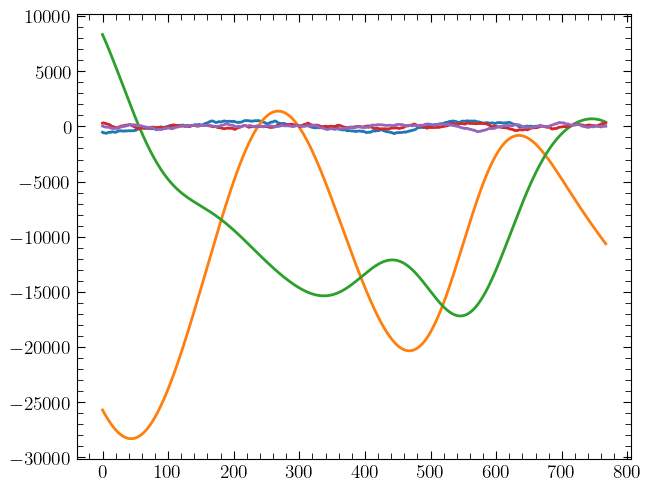

In [6]:
plt.plot(fields_orig[0]) # fields_forg
plt.plot(fields_forg[0]) # fields_forgplt.plot(fields_forg[0]) # fields_forg
plt.plot(fields_forg[1]) # fields_forgplt.plot(fields_forg[0]) # fields_forg
plt.plot(fields_21cm[0]) # fields_forgplt.plot(fields_forg[0]) # fields_forg
plt.plot(fields_21cm[1]) # fields_forgplt.plot(fields_forg[0]) # fields_forg


In [7]:
1-len(np.nonzero(flag)[0])/N

0.28125

In [8]:
pk_recovered = []

for field in fields_flag:
    fk = np.fft.fft(field)
    pk_fft = (L / N**2) * (fk * fk.conjugate()).real
    pk_recovered.append(pk_fft)
    
pk_recovered = np.array(pk_recovered)
pk_recovered_fft = pk_recovered


# n1 = 1
# nend = N//2
# k_vals = k_abs[n1:nend]
# P_theory = P_cont

# k_centers, p_rec_mean, p_rec_err, binned_th, bins = bin_power_spectrum(
#     n1, nend, k_vals, pk_recovered, P_theory, NB
# )


# fig, axes = plot_power_with_ratio(k_centers, p_rec_mean, p_rec_err, binned_th,
#                                   theory_label='EoR Model')
# plt.show()


In [9]:

M = np.argmax(ml.real == 0) if np.any(ml.real == 0) else ml.shape[0] # only where cl is valid, ie, discarding last few delta nu
# M = N // 2
print(M)


# DCT k-grid the correlation length
k_dct = np.pi * np.arange(M) / ((M-1) * dL)   # k_n = n*pi / L_eff, L_eff = (M-1)*dx

# --- theory on DCT grid (for comparison to pk_dct) ---
P_cont_dct = np.interp(k_dct, k_model, P_model, left=0, right=0)


pk_recovered = []
for field in fields_flag:
    # field *= flag
    cl_full = pfunc.covtocl_fast(field, field)/ml

    # Use only M-terms of the correlation:
    cl = cl_full[:M]              # shape (M,)
    w =  windows.nuttall(2*M)[M:]

    # --- DCT estimator (discrete Wiener–Khinchin for half-corr, cosine basis) ---
    pk_dct = dL * idct(cl.real * w, type=1)
    pk_recovered.append(pk_dct)

pk_recovered = np.array(pk_recovered)   # shape (Nrea, M)
pk_recovered_dct = pk_recovered

# ----------------------------
# Binning in k (DCT grid)
# ----------------------------

# # choose a safe k-range away from DC/Nyquist
# n1   = 1
# nend = M 
# k_vals = k_dct[n1:nend]                # DCT k-grid in this range
# P_theory = P_cont_dct
# k_centers, p_rec_mean, p_rec_err, binned_th, bins = bin_power_spectrum(
#     n1, nend, k_vals, pk_recovered, P_theory, NB
# )


# fig, axes = plot_power_with_ratio(k_centers, p_rec_mean, p_rec_err, binned_th,
#                                   theory_label='EoR Model')
# plt.show()


668


In [10]:
ml.shape, M

((668,), 668)

/home/asif/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/asif/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


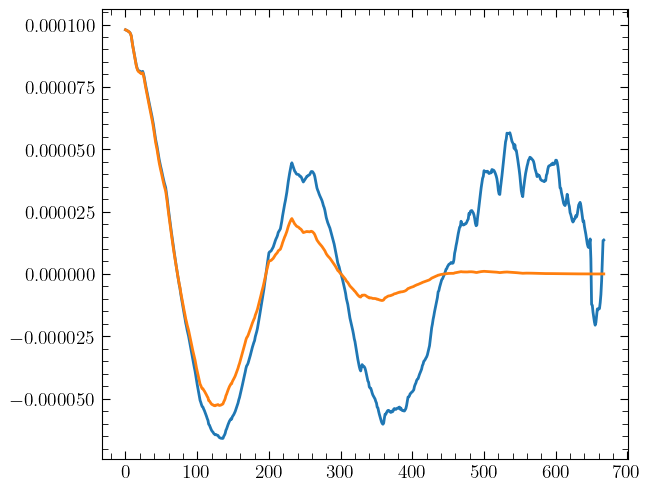

In [11]:
Omi = 1/(4*np.pi*r**2)
plt.plot(cl*Omi)
plt.plot(cl*Omi*w)


In [12]:
# def plot_compare_estimators(
#         k_fft, mean_fft, err_fft, binned_th_fft,
#         k_dct, mean_dct, err_dct, binned_th_dct,
#         theory_label='Theory',
#         fft_label=r'$|T(\tau)|^2$', dct_label='$DCT(C_\ell(Delta\nu))$',
#         figsize=(7, 8), title=None, save=True,
#         figname='compare_estimators.pdf',
#         band=True, band_alpha=0.15,
#         ylim=None, clip_symbol=True):

#     fig = plt.figure(figsize=figsize)
#     gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

#     # ---- TOP PANEL ----
#     ax1 = fig.add_subplot(gs[0])
#     ax1.errorbar(k_fft, np.abs(mean_fft), err_fft, fmt='o', ls='--', label=fft_label)
#     ax1.errorbar(k_dct, np.abs(mean_dct), err_dct, fmt='s', ls='--', label=dct_label)

#     ax1.plot(k_fft, binned_th_fft, '-k', lw=2, label=theory_label)
#     ax1.plot(k_dct, binned_th_dct, '-k', lw=2)

#     ax1.set_yscale('log')
#     ax1.set_ylabel(r'$P(k_\parallel)$')
#     ax1.grid(alpha=0.3)
#     ax1.legend()
#     ax1.tick_params(labelbottom=False)

#     if title:
#         ax1.set_title(title, fontsize=13)

#     # ---- BOTTOM PANEL ----
#     ax2 = fig.add_subplot(gs[1], sharex=ax1)

#     ratio_fft = 100 * (mean_fft / binned_th_fft - 1)
#     ratio_dct = 100 * (mean_dct / binned_th_dct - 1)

#     err_fft_scaled = 100 * err_fft / binned_th_fft
#     err_dct_scaled = 100 * err_dct / binned_th_dct

#     def plot_clipped(ax, k, y, dy, marker, label):
#         """Plot keeping in-range points and marking clipped values with arrows in same colour."""

#         # If no clipping → standard plotting
#         if ylim is None:
#             ax.errorbar(k, y, dy, fmt=marker, capsize=4, label=label)
#             return

#         # Masks
#         mask_in = np.abs(y) <= ylim
#         mask_up = y > ylim
#         mask_down = y < -ylim

#         # Plot in-range points and capture color
#         if np.any(mask_in):
#             line = ax.errorbar(k[mask_in], y[mask_in], dy[mask_in],
#                                fmt=marker, capsize=3, label=label)
#             color = line[0].get_color()
#         else:
#             # No valid points → extract color from dummy
#             tmp = ax.plot([], [], marker=marker)[0]
#             color = tmp.get_color()

#         # Draw clipped arrows using TEXT (not fmt marker)
#         if clip_symbol:
#             if np.any(mask_up):
#                 for xi in k[mask_up]:
#                     ax.text(xi, ylim*0.8, "\u2191", color=color,
#                             fontsize=14, ha='center', va='bottom')

#             if np.any(mask_down):
#                 for xi in k[mask_down]:
#                     ax.text(xi, -ylim*0.8, "\u2193", color=color,
#                             fontsize=14, ha='center', va='top')


#     # Draw curves with clipping logic
#     plot_clipped(ax2, k_fft, ratio_fft, err_fft_scaled, 'o', fft_label)
#     plot_clipped(ax2, k_dct, ratio_dct, err_dct_scaled, 's', dct_label)

#     # error band (FFT reference)
#     ax2.fill_between(k_fft, -err_fft_scaled, err_fft_scaled, alpha=band_alpha)
#     ax2.fill_between(k_dct, -err_dct_scaled, err_dct_scaled, alpha=band_alpha)

#     ax2.axhline(0, color='k', ls='--')
#     ax2.set_xlabel(r'$k_\parallel$')
#     ax2.set_ylabel('% deviation')
#     ax2.grid(alpha=0.3)

#     if ylim is not None:
#         ax2.set_ylim(-ylim, ylim)

#     if save:
#         fig.savefig(figname, bbox_inches='tight')
#         print(f"Saved:", figname)

#     return fig, (ax1, ax2)

In [13]:



# import matplotlib.pyplot as plt
# import numpy as np

# def plot_compare_estimators(
#         k_fft, mean_fft, err_fft, binned_th_fft,
#         k_dct, mean_dct, err_dct, binned_th_dct,
#         theory_label=r'${\rm EoR\,Model}$',
#         fft_label=r'${\rm Delay\,spectrum\,squared}$', 
#         dct_label=r'${\rm Fourier\, transform \, of \, C_\ell(\Delta\nu)}$',
#         figsize=(7, 8), title=None, save=True,
#         figname='compare_estimators.pdf',
#         fft_color='C0', dct_color = 'C1',
#         band=True, band_alpha=0.15,
#         ylim=None, clip_symbol=True):

#     fig = plt.figure(figsize=figsize)
#     gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

#     # ---- TOP PANEL: Power spectra ----
#     ax1 = fig.add_subplot(gs[0])

#     # FFT estimator
#     fft_line = ax1.errorbar(k_fft, np.abs(mean_fft), err_fft,
#                             fmt='o', ls='--', label=fft_label)
#     fft_color = fft_line[0].get_color()


#     # DCT estimator
#     dct_line = ax1.errorbar(k_dct, np.abs(mean_dct), err_dct,
#                             fmt='s', ls='--', label=dct_label)
#     dct_color = dct_line[0].get_color()


#     # Theory
#     ax1.plot(k_fft, binned_th_fft, '-k', lw=2, label=theory_label)
#     ax1.plot(k_dct, binned_th_dct, '-k', lw=2)

#     ax1.set_yscale('log')
#     ax1.set_ylabel(r'$P(k_\parallel)\,{\rm mK}^2\, {\rm Mpc}^3$')
#     ax1.grid(alpha=0.3)
#     ax1.legend()
#     ax1.tick_params(labelbottom=False)

#     if title:
#         ax1.set_title(title)

#     # ---- BOTTOM PANEL: Ratios ----
#     ax2 = fig.add_subplot(gs[1], sharex=ax1)

#     ratio_fft = 100 * (mean_fft / binned_th_fft - 1)
#     ratio_dct = 100 * (mean_dct / binned_th_dct - 1)

#     err_fft_scaled = 100 * err_fft / binned_th_fft
#     err_dct_scaled = 100 * err_dct / binned_th_dct

#     def plot_clipped(ax, k, y, dy, marker, label):
#         """
#         Plot data normally within ylim.
#         Points outside ylim are marked using ↑/↓ arrows in matching color.
#         """
#         if ylim is None:
#             ax.errorbar(k, y, dy, fmt=marker, capsize=4, label=label)
#             return

#         mask_in = np.abs(y) <= ylim
#         mask_up = y > ylim
#         mask_down = y < -ylim

#         # Plot valid points and get assigned color
#         if np.any(mask_in):
#             line = ax.errorbar(k[mask_in], y[mask_in], dy[mask_in],
#                                fmt=marker, capsize=3, label=label)
#             color = line[0].get_color()
#         else:
#             tmp = ax.plot([], [], marker=marker)[0]
#             color = tmp.get_color()

#         # Place unicode arrows for clipped points
#         if clip_symbol:
#             if np.any(mask_up):
#                 for xi in k[mask_up]:
#                     ax.text(xi, ylim * 0.8, r'$\uparrow$',
#                             ha='center', va='bottom', fontsize=16, color=color)

#             if np.any(mask_down):
#                 for xi in k[mask_down]:
#                     ax.text(xi, -ylim * 0.8, r'$\downarrow$',
#                             ha='center', va='top', fontsize=16, color=color)

#     # Draw clipped or normal points
#     plot_clipped(ax2, k_fft, ratio_fft, err_fft_scaled, 'o', fft_label)
#     plot_clipped(ax2, k_dct, ratio_dct, err_dct_scaled, 's', dct_label)

#     # ---- Uncertainty bands using matching colors ----
#     if band:
#         # FFT band
#         temp_fft = ax2.errorbar(k_fft, ratio_fft, err_fft_scaled, fmt='o', alpha=0)[0]
#         # fft_color = temp_fft.get_color()
#         ax2.fill_between(k_fft, -err_fft_scaled, err_fft_scaled,
#                          color=fft_color, alpha=band_alpha, label="_nolegend_")

#         # DCT band
#         temp_dct = ax2.errorbar(k_dct, ratio_dct, err_dct_scaled, fmt='s', alpha=0)[0]
#         # dct_color = temp_dct.get_color()
#         # dct_color = dct_line[0].get_color()

#         ax2.fill_between(k_dct, -err_dct_scaled, err_dct_scaled,
#                          color=dct_color, alpha=band_alpha, label="_nolegend_")

#     # Axes decoration
#     ax2.axhline(0, color='k', ls='--')
#     ax2.set_xlabel(r'$k_\parallel$')
#     ax2.set_ylabel(r'\rm{Percentage deviation (\%)}')
#     ax2.grid(alpha=0.3)
#     fig.align_ylabels()
#     if ylim is not None:
#         ax2.set_ylim(-ylim, ylim)

#     if save:
#         fig.savefig(figname, bbox_inches='tight')
#         print(f"Saved:", figname)
    
#     return fig, (ax1, ax2)


In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_compare_estimators(
        k_fft, mean_fft, err_fft, binned_th_fft,
        k_dct, mean_dct, err_dct, binned_th_dct,
        theory_label=r'${\rm EoR\,Model}$',
        fft_label=r'${\rm Delay\,spectrum\,squared}$',
        dct_label=r'${\rm Fourier\, transform \, of \, C_\ell(\Delta\nu)}$',
        fft_dev_label=r'\rm{FFT\ deviation\ (\%)}',      # NEW
        dct_dev_label=r'\rm{DCT\ deviation\ (\%)}',      # NEW
        figsize=(7, 10),
        title=None, save=True,
        figname='compare_estimators.pdf',
        fft_color='C0', dct_color='C1',
        band=True, band_alpha=0.15,
        ylim=None, clip_symbol=True):

    fig = plt.figure(figsize=figsize)

    # ----------------------------
    # NEW: 3 rows: top, FFT deviation, DCT deviation
    # ----------------------------
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 1], hspace=0.07)

    # ============================================================
    # TOP PANEL — Power spectra
    # ============================================================
    ax1 = fig.add_subplot(gs[0])

    fft_line = ax1.errorbar(k_fft, np.abs(mean_fft), err_fft,
                            fmt='o', ls='--', label=fft_label)
    fft_color = fft_line[0].get_color()

    dct_line = ax1.errorbar(k_dct, np.abs(mean_dct), err_dct,
                            fmt='s', ls='--', label=dct_label)
    dct_color = dct_line[0].get_color()

    ax1.plot(k_fft, binned_th_fft, '-k', lw=2, label=theory_label)
    ax1.plot(k_dct, binned_th_dct, '-k', lw=2)

    ax1.set_yscale('log')
    ax1.set_ylabel(r'$P(k_\parallel)\,{\rm mK}^2\, {\rm Mpc}^3$')
    ax1.grid(alpha=0.3)
    ax1.legend()
    ax1.tick_params(labelbottom=False)

    if title:
        ax1.set_title(title)

    # ============================================================
    # Prepare ratios (same as before)
    # ============================================================
    ratio_fft = 100 * (mean_fft / binned_th_fft - 1)
    ratio_dct = 100 * (mean_dct / binned_th_dct - 1)

    err_fft_scaled = 100 * err_fft / binned_th_fft
    err_dct_scaled = 100 * err_dct / binned_th_dct

    # ===== Helper for clipped symbols =====
    def plot_clipped(ax, k, y, dy, marker, label, color=None):
        if ylim is None:
            ax.errorbar(k, y, dy, fmt=marker, capsize=4,
                        label=label, color=color)
            return

        mask_in = np.abs(y) <= ylim
        mask_up = y > ylim
        mask_down = y < -ylim

        if np.any(mask_in):
            line = ax.errorbar(k[mask_in], y[mask_in], dy[mask_in],
                               fmt=marker, capsize=3, label=label,
                               color=color)
            c = line[0].get_color()
        else:
            c = color

        if clip_symbol:
            if np.any(mask_up):
                for xi in k[mask_up]:
                    ax.text(xi, ylim * 0.8, r'$\uparrow$', ha='center',
                            va='bottom', fontsize=16, color=c)
            if np.any(mask_down):
                for xi in k[mask_down]:
                    ax.text(xi, -ylim * 0.8, r'$\downarrow$', ha='center',
                            va='top', fontsize=16, color=c)

    # ============================================================
    # MIDDLE PANEL — FFT percentage deviation
    # ============================================================
    ax_fft = fig.add_subplot(gs[1], sharex=ax1)    # NEW

    plot_clipped(ax_fft, k_fft, ratio_fft, err_fft_scaled,
                 'o', fft_label, color=fft_color)

    if band:
        ax_fft.fill_between(k_fft, -err_fft_scaled, err_fft_scaled,
                            color=fft_color, alpha=band_alpha,
                            label="_nolegend_")

    ax_fft.axhline(0, color='k', ls='--')
    # ax_fft.set_ylabel(r'\rm{FFT deviation (\%)}')
    ax_fft.set_ylabel(fft_dev_label)     # NEW
    ax_fft.grid(alpha=0.3)
    ax_fft.tick_params(labelbottom=False)

    if ylim is not None:
        ax_fft.set_ylim(-ylim, ylim)

    # ============================================================
    # BOTTOM PANEL — DCT percentage deviation
    # ============================================================
    ax_dct = fig.add_subplot(gs[2], sharex=ax1)    # NEW

    plot_clipped(ax_dct, k_dct, ratio_dct, err_dct_scaled,
                 's', dct_label, color=dct_color)

    if band:
        ax_dct.fill_between(k_dct, -err_dct_scaled, err_dct_scaled,
                            color=dct_color, alpha=band_alpha,
                            label="_nolegend_")

    ax_dct.axhline(0, color='k', ls='--')
    # ax_dct.set_ylabel(r'\rm{DCT deviation (\%)}')
    ax_dct.set_ylabel(dct_dev_label)     # NEW
    ax_dct.grid(alpha=0.3)

    if ylim is not None:
        ax_dct.set_ylim(-ylim, ylim)

    ax_dct.set_xlabel(r'$k_\parallel$')

    fig.align_ylabels()

    if save:
        fig.savefig(figname, bbox_inches='tight')
        print("Saved:", figname)

    return fig, (ax1, ax_fft, ax_dct)


In [15]:
n1_fft = 1
nend_fft = N // 2

k_fft_vals = k_abs[n1_fft:nend_fft]
P_theory_fft = P_cont

kb_fft, mean_fft, err_fft, binned_th_fft, bins_fft = pfunc.bin_power_spectrum(
    n1_fft, nend_fft, k_fft_vals, pk_recovered_fft, P_theory_fft, NB
)



n1_dct = 1
nend_dct = M   # from your DCT logic

k_dct_vals = k_dct[n1_dct:nend_dct]
P_theory_dct = P_cont_dct

kb_dct, mean_dct, err_dct, binned_th_dct, bins_dct = pfunc.bin_power_spectrum(
    n1_dct, nend_dct, k_dct_vals, pk_recovered_dct, P_theory_dct, NB
)


In [16]:
# fig, axes = plot_compare_estimators(
#     k_fft, mean_fft, err_fft, binned_th_fft,
#     k_dct, mean_dct, err_dct, binned_th_dct,
#     title="Recovered Power Spectrum: FFT vs DCT",
#     theory_label="EoR Model"
# )

# plt.show()


In [17]:
import numpy as np

def save_dct(fname_prefix, fg, flag, scf, method,
             kb_dct, mean_dct, err_dct, binned_th_dct):

    fname = f"{fname_prefix}_fg-{fg}_flag-{flag}_scf-{scf}_method-{method}.npz"

    np.savez(
        fname,
        kb_dct=kb_dct,
        mean_dct=mean_dct,
        err_dct=err_dct,
        binned_th_dct=binned_th_dct,
        fg=fg,
        flag=flag,
        scf=scf,
        method=method
    )

    print("Saved:", fname)
    return fname




In [18]:
save_dct("dct", fg="fg21", flag=f"{mode}", scf="yes", method=f"{SCF}", # or GP or DPSS in method
         kb_dct=kb_dct,
         mean_dct=mean_dct,
         err_dct=err_dct,
         binned_th_dct=binned_th_dct)

save_dct("fft", fg="fg21", flag=f"{mode}", scf="yes", method=f"{SCF}", # or GP or DPSS in method
         kb_dct=kb_fft,
         mean_dct=mean_fft,
         err_dct=err_fft,
         binned_th_dct=binned_th_fft)



Saved: dct_fg-fg21_flag-PERIODIC_scf-yes_method-Hann.npz
Saved: fft_fg-fg21_flag-PERIODIC_scf-yes_method-Hann.npz


'fft_fg-fg21_flag-PERIODIC_scf-yes_method-Hann.npz'

In [19]:
data = np.load(f"dct_fg-fg21_flag-{mode}_scf-yes_method-{SCF}.npz")

kb_dct          = data["kb_dct"]
mean_dct        = data["mean_dct"]
err_dct         = data["err_dct"]
binned_th_dct   = data["binned_th_dct"]

fg              = data["fg"].tolist()
flag            = data["flag"].tolist()
scf             = data["scf"].tolist()
method          = data["method"].tolist()


data = np.load(f"fft_fg-fg21_flag-{mode}_scf-yes_method-{SCF}.npz")

kb_fft          = data["kb_dct"]
mean_fft        = data["mean_dct"]
err_fft         = data["err_dct"]
binned_th_fft   = data["binned_th_dct"]

# fg              = data["fg"].tolist()
# flag            = data["flag"].tolist()
# scf             = data["scf"].tolist()
# method          = data["method"].tolist()


Saved: Data_FG21_SCF_Hann_Flag_PERIODIC.pdf


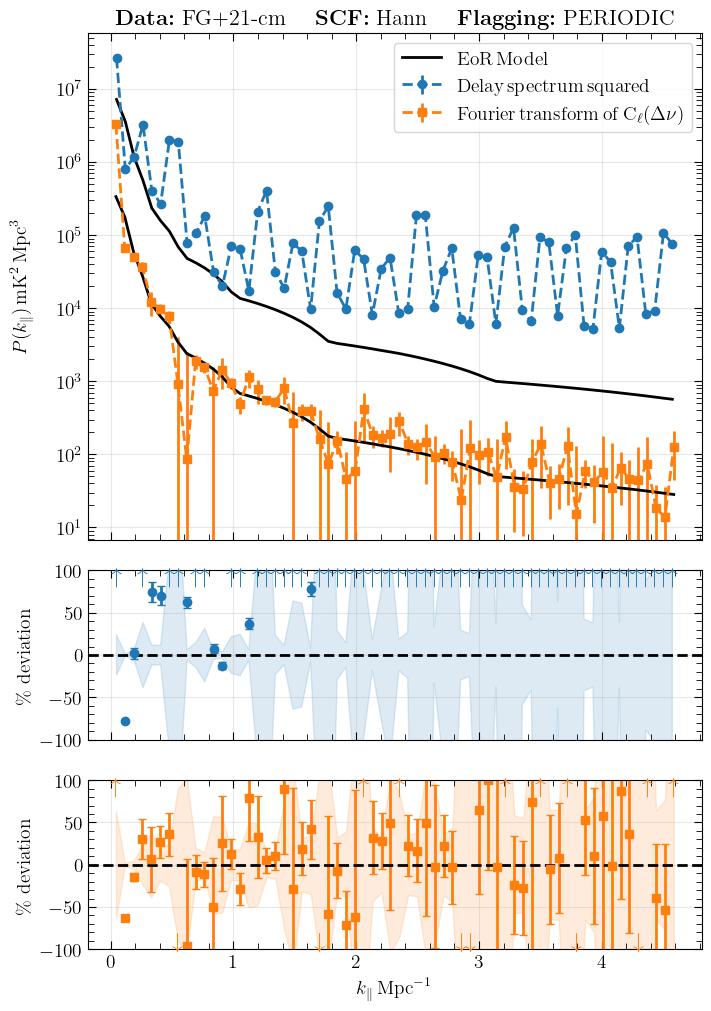

In [20]:
# shift = 20.0   # upward shift for clarity
# offset_ratio = 10000.0  # shift 2 percentage points in ratio plot (optional)
# fig, axes = plot_compare_estimators(
#     kb_fft, mean_fft * shift, err_fft*shift, binned_th_fft* shift,
#     kb_dct, mean_dct, err_dct, binned_th_dct,
#     title = r"\rm{  {\bf Data:}~FG+21-cm} \quad" + r"\rm{{\bf SCF:}~" +fr"$\rm{{ {SCF} }}  \quad$"  + r"\rm{ {\bf Flagging:}~"+fr"$\rm{{ {mode} }} $",
#     fft_dev_label=r'\rm{\% deviation}',
#     dct_dev_label=r'\rm{\% deviation}',
#     # title = r"$\bf{{Data:}}$",
#     figname=f'flag_{mode}.pdf',
#     ylim=100
# )



shift = 20.0   # upward shift for clarity
offset_ratio = 10000.0  # shift 2 percentage points in ratio plot (optional)

figname = f"Data_FG21_SCF_{SCF}_Flag_{mode}.pdf"  

fig, axes = plts.plot_compare_estimators(
    kb_fft, mean_fft * shift, err_fft*shift, binned_th_fft* shift,
    kb_dct, mean_dct, err_dct, binned_th_dct,
    fft_label=r'${\rm Delay\,spectrum\,squared}$',
    dct_label=r'${\rm Fourier\, transform \, of \, C_\ell(\Delta\nu)}$',
    title = r"\rm{  {\bf Data:}~FG+21-cm} \quad" + r"\rm{{\bf SCF:}~" +fr"$\rm{{ {SCF} }}  \quad$"  + r"\rm{ {\bf Flagging:}~"+fr"$\rm{{ {mode} }} $",
    fft_dev_label=r'\rm{\% deviation}',
    dct_dev_label=r'\rm{\% deviation}',
    fft_color='C0', dct_color='C1',
    # title = r"$\bf{{Data:}}$",
    figname=figname,
    ylim=100
)
